# Análisis Exploratorio — Búsquedas Hoteleras

Este notebook carga los datos históricos de búsquedas de la plataforma ID90Travel y recorre las etapas del pipeline de procesamiento paso a paso.

**Antes de empezar**: asegurarse de tener los archivos `datos_historicos_*.csv` en la carpeta `data/`. Ver instrucciones de descarga en el README (sección *Para Estudiantes — Mentoría DiploDatos 2026*).

## Pipeline que vamos a recorrer

```
CSV(s) en data/
   → 1. Carga y exploración inicial
   → 2. Normalización de precios
   → 3. Expansión temporal (estadía multi-noche → observaciones diarias)
   → 4. Features temporales (mes, semana del mes)
   → 5. Mapping de destinos
   → 6. Cálculo de baselines estadísticos
   → 7. Clasificación de un precio de ejemplo
```

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Importar funciones del sistema
sys.path.insert(0, str(Path('.').resolve()))
from auxiliary_functions import (
    load_all_historicals,
    load_destination_mapping,
    standardize_prices,
    expand_dates_dataframe,
    add_temporal_features,
    apply_destination_mapping,
    calculate_baselines,
    apply_robustness_checks,
    evaluate_hotel_price,
)
import config

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)
print('Librerías importadas correctamente')
print(f'Directorio de datos: {config.DATA_DIR}')

Librerías importadas correctamente
Directorio de datos: /home/martin/Desktop/hotels/deals_analysis/data


---
## Paso 1 — Carga de datos

**Función `load_all_historicals()`**: busca todos los archivos `datos_historicos_*.csv` en `config.DATA_DIR`, los carga con `pd.read_csv` y los concatena en un único DataFrame. Si hay varios años disponibles, todos quedan en un mismo DataFrame listo para procesar.

> **Nota sobre esta demostración**: se carga una **muestra de 100.000 registros** del primer archivo disponible para mantener tiempos de ejecución razonables. Para el análisis completo (TP2 y TP3), reemplazar la celda de carga por `df_raw = load_all_historicals()` con todos los archivos descargados.

In [2]:
import glob

# Para carga completa de todos los años:
# df_raw = load_all_historicals()

# Para esta demostración usamos una muestra de 100.000 registros:
archivos = sorted(glob.glob(str(config.DATA_DIR / config.HISTORICALS_FILE_PATTERN)))
if not archivos:
    raise FileNotFoundError(f'No se encontraron archivos en {config.DATA_DIR}')

df_raw = pd.read_csv(archivos[0], nrows=100_000)
print(f'Archivo:             {Path(archivos[0]).name}')
print(f'Registros cargados:  {len(df_raw):>12,}  (muestra de 100k)')
print(f'Columnas:            {len(df_raw.columns)}')
print()
print('Lista de columnas:')
for col in df_raw.columns:
    print(f'  - {col}  ({df_raw[col].dtype})')

Archivo:             datos_historicos_2024.csv
Registros cargados:       100,000  (muestra de 100k)
Columnas:            17

Lista de columnas:
  - city  (object)
  - state  (object)
  - country  (object)
  - country_code  (object)
  - date_start  (object)
  - date_end  (object)
  - number_of_adults  (int64)
  - number_of_rooms  (int64)
  - number_of_kids  (int64)
  - nights  (int64)
  - count_repeated  (int64)
  - avg_hotel_count  (float64)
  - min_hotel_count  (int64)
  - max_hotel_count  (int64)
  - avg_price_average  (float64)
  - max_price_high  (float64)
  - min_price_low  (float64)


In [3]:
# Primeras filas del dataset
df_raw.head(3)

,city,state,country,country_code,date_start,date_end,number_of_adults,number_of_rooms,number_of_kids,nights,count_repeated,avg_hotel_count,min_hotel_count,max_hotel_count,avg_price_average,max_price_high,min_price_low
0,남구,Busan,South Korea,kr,2024-03-26,2024-03-30,5,1,0,4,2,22.00,22,22,124.70,227.10,54.63
1,동구,Busan,South Korea,kr,2024-03-01,2024-03-04,4,2,0,3,1,5.00,5,5,108.69,173.39,52.84
2,동구,Busan,South Korea,kr,2024-03-02,2024-03-04,2,1,0,2,2,5.00,5,5,77.50,126.86,47.04


In [4]:
# Cobertura temporal y geográfica
print('COBERTURA DEL DATASET')
print('=' * 45)
print(f"  Fecha inicio:       {df_raw['date_start'].min()}")
print(f"  Fecha fin:          {df_raw['date_start'].max()}")
print(f"  Países:             {df_raw['country'].nunique()}")
print(f"  Estados/Provincias: {df_raw['state'].nunique():,}")
print(f"  Ciudades:           {df_raw['city'].nunique():,}")
print()
print('DEMANDA (count_repeated = búsquedas agregadas)')
print('=' * 45)
print(f"  Total búsquedas:    {df_raw['count_repeated'].sum():,.0f}")
print(f"  Media por registro: {df_raw['count_repeated'].mean():.1f}")
print()
print('PRECIOS (avg_price_average)')
print('=' * 45)
df_raw['avg_price_average'].describe()

COBERTURA DEL DATASET
  Fecha inicio:       2024-01-01
  Fecha fin:          2024-12-30
  Países:             102
  Estados/Provincias: 383
  Ciudades:           1,222

DEMANDA (count_repeated = búsquedas agregadas)
  Total búsquedas:    584,080
  Media por registro: 5.8

PRECIOS (avg_price_average)


count   100000.00
mean       256.64
std        491.66
min          9.38
25%        128.58
50%        175.09
75%        256.52
max      43310.77
Name: avg_price_average, dtype: float64

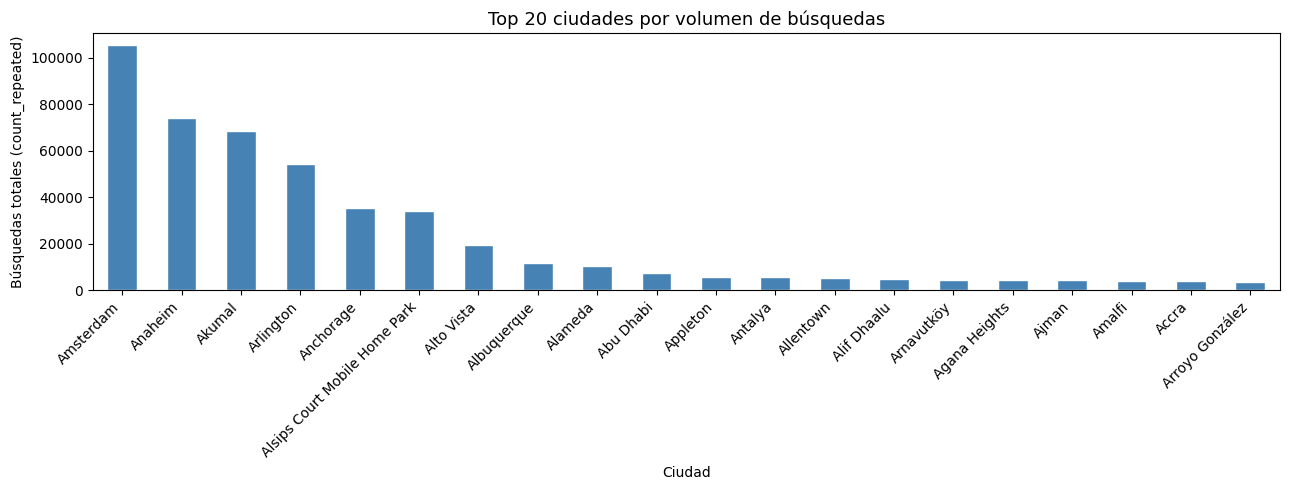

--- Pregunta para TP1 ---
¿La distribución de demanda es uniforme o hay destinos dominantes?
Top 5 ciudades concentran el 57.9% del total de búsquedas.


In [5]:
# TP1: Top destinos por volumen de búsquedas
top_dest = (
    df_raw.groupby('city')['count_repeated']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(13, 5))
top_dest.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 ciudades por volumen de búsquedas', fontsize=13)
ax.set_xlabel('Ciudad')
ax.set_ylabel('Búsquedas totales (count_repeated)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('--- Pregunta para TP1 ---')
print('¿La distribución de demanda es uniforme o hay destinos dominantes?')
top5_pct = top_dest.head(5).sum() / df_raw['count_repeated'].sum()
print(f'Top 5 ciudades concentran el {top5_pct:.1%} del total de búsquedas.')

---
## Paso 2 — Normalización de precios

Las búsquedas no son directamente comparables entre sí: una estadía de 7 noches con 2 habitaciones y 4 personas tiene un precio total muy distinto a una de 1 noche para 1 persona, aunque el precio unitario sea el mismo.

La normalización convierte todos los precios a una unidad común:

```
precio_normalizado = precio_total / (noches × habitaciones × (adultos + niños))
```

Esto produce un **precio por persona por habitación por noche**, comparable entre búsquedas de cualquier composición. Esta es la variable central de análisis del sistema.

In [6]:
# Eliminar duplicados antes de procesar
registros_antes = len(df_raw)
df = df_raw.drop_duplicates()
print(f'Duplicados eliminados: {registros_antes - len(df):,}')
print()

# Normalizar precios
df = standardize_prices(df)
print('Nuevas columnas agregadas:')
print('  - avg_price_average_std  (precio promedio normalizado)')
print('  - max_price_high_std     (precio máximo normalizado)')
print('  - min_price_low_std      (precio mínimo normalizado)')
print()
print('Comparación precio total vs. precio normalizado:')
df[['avg_price_average', 'avg_price_average_std']].describe()

2026-05-19 12:05:00,258 - INFO - ✓ Precios estandarizados: 100,000 registros


Duplicados eliminados: 0

Nuevas columnas agregadas:
  - avg_price_average_std  (precio promedio normalizado)
  - max_price_high_std     (precio máximo normalizado)
  - min_price_low_std      (precio mínimo normalizado)

Comparación precio total vs. precio normalizado:


,avg_price_average,avg_price_average_std
count,100000.00,100000.00
mean,256.64,241.38
std,491.66,475.29
min,9.38,0.10
25%,128.58,119.56
50%,175.09,168.24
75%,256.52,248.49
max,43310.77,43310.77


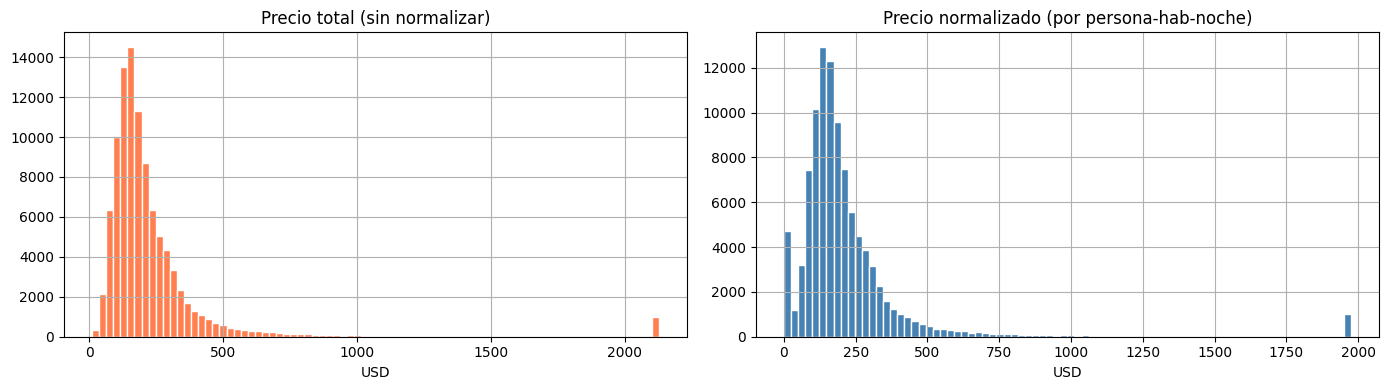

¿Por qué cambia la forma de la distribución con la normalización?


In [7]:
# Distribución del precio antes y después de normalizar
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

clip_raw = df['avg_price_average'].quantile(0.99)
df['avg_price_average'].clip(upper=clip_raw).hist(
    bins=80, ax=axes[0], color='coral', edgecolor='white'
)
axes[0].set_title('Precio total (sin normalizar)')
axes[0].set_xlabel('USD')

clip_std = df['avg_price_average_std'].quantile(0.99)
df['avg_price_average_std'].clip(upper=clip_std).hist(
    bins=80, ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Precio normalizado (por persona-hab-noche)')
axes[1].set_xlabel('USD')

plt.tight_layout()
plt.show()

print('¿Por qué cambia la forma de la distribución con la normalización?')

---
## Paso 3 — Expansión temporal

Cada registro representa una estadía que abarca múltiples noches. Para construir distribuciones de precio con resolución semanal (semana del mes), es necesario que **cada noche** aparezca como una observación independiente.

Este paso transforma cada registro de estadía en N registros diarios, donde N = número de noches. El dataset crece aproximadamente 4x.

In [8]:
registros_antes = len(df)
df = expand_dates_dataframe(df)
print(f'Registros antes:   {registros_antes:>12,}')
print(f'Registros después: {len(df):>12,}')
print(f'Factor expansión:  {len(df)/registros_antes:.2f}x')
print(f'\nNueva columna: date (fecha individual de cada noche de la estadía)')
df[['date_start', 'date_end', 'nights', 'date']].head()

2026-05-19 12:05:00,636 - INFO - Expandiendo 100,000 registros a días (versión optimizada)...


2026-05-19 12:05:00,849 - INFO - ✓ Expansión: 100,000 → 438,858 observaciones diarias


Registros antes:        100,000
Registros después:      438,858
Factor expansión:  4.39x

Nueva columna: date (fecha individual de cada noche de la estadía)


,date_start,date_end,nights,date
0,2024-03-26,2024-03-30,4,2024-03-26
0,2024-03-26,2024-03-30,4,2024-03-27
0,2024-03-26,2024-03-30,4,2024-03-28
0,2024-03-26,2024-03-30,4,2024-03-29
0,2024-03-26,2024-03-30,4,2024-03-30


---
## Paso 4 — Features temporales

Se agregan dos columnas que el sistema usa para segmentar el tiempo:
- `month`: mes del año (1–12)
- `week_in_month`: semana del mes (1–4) — días 1–7, 8–15, 16–22, 23–31

Estas variables permiten que el sistema reconozca, por ejemplo, que la **tercera semana de diciembre** (pre-Navidad) tiene un perfil de precios estructuralmente diferente al de la primera semana del mismo mes en el mismo destino.

In [9]:
df = add_temporal_features(df)
print('Columnas agregadas: month, week_in_month')
df[['date', 'month', 'week_in_month']].head()

2026-05-19 12:05:00,941 - INFO - Features temporales generadas: month, week_in_month


Columnas agregadas: month, week_in_month


,date,month,week_in_month
0,2024-03-26,3,4
0,2024-03-27,3,4
0,2024-03-28,3,4
0,2024-03-29,3,4
0,2024-03-30,3,4


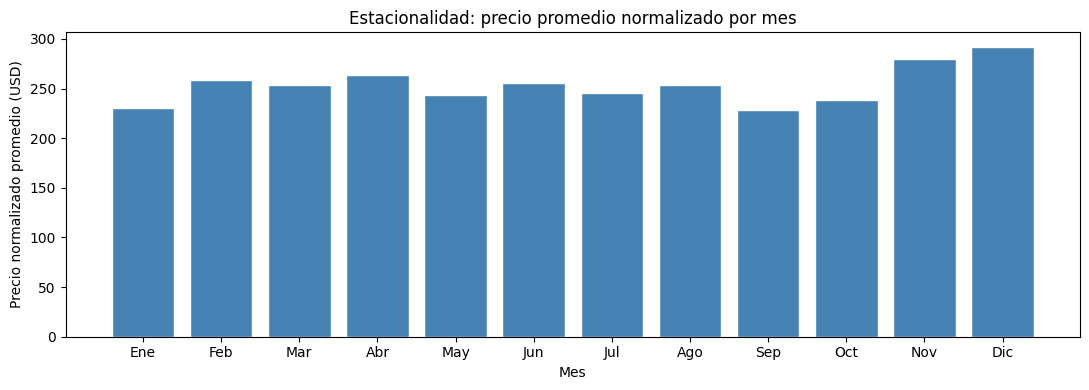

--- Pregunta para TP1 ---
¿Qué meses muestran precios más altos? ¿Tiene sentido con la lógica del negocio de viajes?
¿La estacionalidad es igual para todos los destinos o varía por mercado?


In [10]:
# TP1: Estacionalidad — precio normalizado promedio por mes
precios_mes = (
    df.groupby('month')['avg_price_average_std']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(precios_mes['month'], precios_mes['avg_price_average_std'],
       color='steelblue', edgecolor='white')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio normalizado promedio (USD)')
ax.set_title('Estacionalidad: precio promedio normalizado por mes')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
plt.tight_layout()
plt.show()

print('--- Pregunta para TP1 ---')
print('¿Qué meses muestran precios más altos? ¿Tiene sentido con la lógica del negocio de viajes?')
print('¿La estacionalidad es igual para todos los destinos o varía por mercado?')

---
## Paso 5 — Mapping de destinos (combinación de índices)

El dataset contiene ~26.000 nombres de ciudades distintos, muchos de ellos variantes del mismo lugar. Para construir distribuciones estadísticas confiables es necesario consolidar esas variantes en un único identificador de mercado.

**Función `load_destination_mapping()`**: carga `data/destination_with_nearest.csv` e indexa las filas por la clave compuesta `country_code - state_code - city`. Esta clave de tres partes es fundamental: el mismo nombre de ciudad puede existir en distintos países o estados (por ejemplo, "Springfield" existe en decenas de estados de EE.UU.), por lo que incluir los tres niveles evita ambigüedades.

**Función `apply_destination_mapping(df, mapping_df)`**: construye la misma clave compuesta en el DataFrame principal y realiza un left join contra el índice del mapping. Las ciudades que coinciden reciben su `destination_final` (ID numérico) y `destination_name` (nombre canónico). Las que no coinciden quedan con `NaN` y el pipeline usa el nombre de ciudad como fallback.

> **Hipótesis a evaluar en el TP2**: el criterio de agrupación es proximidad geográfica. ¿Es ese el mejor criterio? ¿Produce grupos con comportamiento de precio homogéneo? El ~40% de registros sin mapeo son los destinos con evidencia histórica más escasa.

In [11]:
mapping_df = load_destination_mapping()
print(f'Referencias en el mapping: {len(mapping_df):,}')
print(f'Destinos canónicos únicos: {mapping_df["nearest_destination_id"].nunique():,}')
print()
print('Estructura del archivo de mapping:')
mapping_df.head()

2026-05-19 12:05:01,230 - INFO - Mapping cargado: 15,988 registros


Referencias en el mapping: 15,988
Destinos canónicos únicos: 2,584

Estructura del archivo de mapping:


,reference,city,latitude,longitude,nearest_destination_id,nearest_destination_name
0,AD - Andorra La Bella,Andorra La Bella,42.51,1.53,50643,Andorra la Vella
1,AD - Andorra La Vella,Andorra La Vella,42.51,1.53,50643,Andorra la Vella
2,AD - Arinsal,Arinsal,42.58,1.48,50643,Andorra la Vella
3,AD - El Pas de la Casa,El Pas de la Casa,42.54,1.73,21795,Andorra
4,AD - Escaldes-Engordany,Escaldes-Engordany,42.51,1.54,50643,Andorra la Vella


In [12]:
df = apply_destination_mapping(df, mapping_df)

print('Resultado del mapping:')
print(f'  Destinos únicos finales:         {df["destination_final"].nunique():,}')
sin_mapeo = df['destination_final'].isna().sum()
print(f'  Sin mapeo (fallback a ciudad):   {sin_mapeo:,} registros ({sin_mapeo/len(df):.1%})')
con_mapeo = (~df['destination_final'].isna()).sum()
print(f'  Con mapeo canónico:              {con_mapeo:,} registros ({con_mapeo/len(df):.1%})')
print()
print('Ejemplo de ciudades mapeadas:')
df[['city', 'state', 'destination_final', 'destination_name']].dropna().head(8)

2026-05-19 12:05:01,664 - INFO - Mapping aplicado: 0/438,858 registros (0.0%)


2026-05-19 12:05:01,674 - INFO - Destinos únicos: 1,222


Resultado del mapping:
  Destinos únicos finales:         1,222
  Sin mapeo (fallback a ciudad):   0 registros (0.0%)
  Con mapeo canónico:              438,858 registros (100.0%)

Ejemplo de ciudades mapeadas:


,city,state,destination_final,destination_name
0,남구,Busan,남구,남구
0,남구,Busan,남구,남구
0,남구,Busan,남구,남구
0,남구,Busan,남구,남구
0,남구,Busan,남구,남구
1,동구,Busan,동구,동구
1,동구,Busan,동구,동구
1,동구,Busan,동구,동구


In [13]:
# Estructura de la clave de combinación entre dataset y mapping
print('Clave de lookup en destination_with_nearest.csv:')
print('  formato: "country_code - state_code - city"')
print()
print('Primeras filas del mapping:')
print(mapping_df[['reference', 'city', 'nearest_destination_id', 'nearest_destination_name']].head())
print()
print('Ciudades mapeadas en el DataFrame principal (muestra):')
muestra = (
    df[['city', 'state', 'country_code', 'destination_final', 'destination_name']]
    .dropna()
    .drop_duplicates('city')
    .head(8)
)
print(muestra.to_string(index=False))

Clave de lookup en destination_with_nearest.csv:
  formato: "country_code - state_code - city"

Primeras filas del mapping:
                 reference                city  nearest_destination_id  \
0    AD - Andorra La Bella    Andorra La Bella                   50643   
1    AD - Andorra La Vella    Andorra La Vella                   50643   
2             AD - Arinsal             Arinsal                   50643   
3   AD - El Pas de la Casa   El Pas de la Casa                   21795   
4  AD - Escaldes-Engordany  Escaldes-Engordany                   50643   

  nearest_destination_name  
0         Andorra la Vella  
1         Andorra la Vella  
2         Andorra la Vella  
3                  Andorra  
4         Andorra la Vella  

Ciudades mapeadas en el DataFrame principal (muestra):
city state country_code destination_final destination_name
  남구 Busan           kr                남구               남구
  동구 Busan           kr                동구               동구
 부암동 Busan           kr 

---
## Paso 6 — Cálculo de baselines

Para cada contexto `(destino, mes, semana del mes)` se calcula la distribución estadística histórica: media ponderada por `count_repeated`, desviación estándar, rango y cantidad de observaciones.

Esta tabla es la **referencia** contra la que se compara cualquier precio nuevo. Contextos con menos de 30 observaciones se marcan como `low_confidence`.

> **Nota**: el pipeline completo (`pipeline_build_baselines.py`) también segmenta por clase de hotel (Budget / Mid-Range / Premium). En este notebook usamos la versión sin segmentación para simplificar.

In [14]:
# Calcular baselines sin segmentación por bucket (versión simplificada para exploración)
baselines = calculate_baselines(df, enable_buckets=False)
baselines = apply_robustness_checks(baselines)

print('BASELINES CALCULADOS')
print('=' * 45)
print(f'  Total de contextos:          {len(baselines):>10,}')
print(f'  Alta confianza (>=30 obs):   {(~baselines["low_confidence"]).sum():>10,}  ({(~baselines["low_confidence"]).mean():.1%})')
print(f'  Baja confianza (<30 obs):    {baselines["low_confidence"].sum():>10,}  ({baselines["low_confidence"].mean():.1%})')
print()
baselines.head()

2026-05-19 12:05:01,839 - INFO - ============================================================


2026-05-19 12:05:01,839 - INFO - CALCULANDO BASELINES


2026-05-19 12:05:01,840 - INFO - ============================================================


2026-05-19 12:05:01,840 - INFO - Agrupación por: ['destination_final', 'month', 'week_in_month']


2026-05-19 12:05:03,450 - INFO - ✓ Baselines calculados: 16,190 contextos


...

2026-05-19 12:05:03,451 - INFO -   Meses cubiertos: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


2026-05-19 12:05:03,534 - INFO - Validaciones aplicadas. Baselines finales: 16,190


2026-05-19 12:05:03,535 - WARNING -   Contextos con baja confianza: 11,584 (71.6%)


BASELINES CALCULADOS
  Total de contextos:              16,190
  Alta confianza (>=30 obs):        4,606  (28.4%)
  Baja confianza (<30 obs):        11,584  (71.6%)



,destination_final,month,week_in_month,mean_price_std,std_price_std,min_price_std,max_price_std,count_obs,destination_name,low_confidence
0,100 Mile House,6,4,84.77,12.14,13.15,116.71,6,100 Mile House,True
1,100 Mile House,7,1,82.57,8.26,13.15,158.16,4,100 Mile House,True
2,100 Mile House,8,1,150.14,15.01,17.95,245.54,4,100 Mile House,True
3,100 Mile House,8,4,97.65,9.77,12.61,169.66,2,100 Mile House,True
4,100 Mile House,9,1,99.06,9.91,73.43,141.29,4,100 Mile House,True


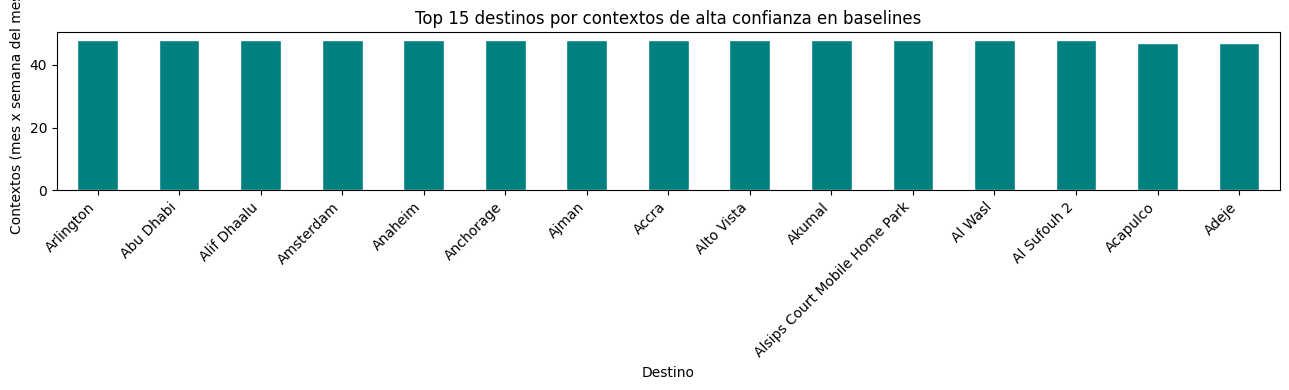

--- Pregunta para TP1/TP2 ---
¿Por qué algunos destinos tienen muchos más contextos que otros?
¿Qué implica para la calidad de la clasificación en destinos menos populares?


In [15]:
# Top destinos por cantidad de contextos de alta confianza
top_baselines = (
    baselines[~baselines['low_confidence']]
    .groupby('destination_name')
    .size()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(13, 4))
top_baselines.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Top 15 destinos por contextos de alta confianza en baselines')
ax.set_xlabel('Destino')
ax.set_ylabel('Contextos (mes x semana del mes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('--- Pregunta para TP1/TP2 ---')
print('¿Por qué algunos destinos tienen muchos más contextos que otros?')
print('¿Qué implica para la calidad de la clasificación en destinos menos populares?')

---
## Paso 7 — Clasificación: z-score contextual

Con los baselines calculados podemos evaluar cualquier precio nuevo. El sistema calcula el **z-score del precio normalizado** respecto a la distribución histórica del contexto:

```
z = (precio_normalizado − media_histórica) / desviación_estándar_histórica
```

El z-score mide cuántas desviaciones estándar está el precio actual respecto al promedio histórico de ese contexto. Un valor negativo indica precio por debajo del promedio; cuanto más negativo, más significativa es la oportunidad.

**Los 4 pasos del cálculo:**
1. **Normalizar el precio**: `precio_std = precio_total / (noches × habitaciones × (adultos + niños))`
2. **Identificar el contexto**: `(destination_final, mes, semana_del_mes)`
3. **Buscar la baseline**: obtener `mean_price_std` y `std_price_std` de la tabla de baselines
4. **Calcular z y clasificar**: `z = (precio_std − mean) / std`, luego aplicar umbrales

**Función `evaluate_hotel_price(destination_final, month, week_in_month, price_std, baselines_df)`**: encapsula los 4 pasos anteriores y devuelve un dict con `classification`, `z_score` y `confidence`. La celda siguiente muestra el mismo cálculo de forma manual.

| Z-score | Clasificación |
|---------|---------------|
| z < -1.0 | **Deal** — precio excepcionalmente bajo |
| -1.0 a -0.5 | **Good Price** |
| -0.5 a +0.5 | **Normal Price** |
| +0.5 a +1.0 | **Expensive** |
| z > +1.0 | **Very Expensive** |

In [16]:
# Ver qué destinos tienen baselines de alta confianza disponibles
dest_disponibles = (
    baselines[~baselines['low_confidence']]
    .groupby(['destination_final', 'destination_name'])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='n_contextos')
)
print('Destinos con más contextos de alta confianza (para usar en el ejemplo):')
print(dest_disponibles.to_string(index=False))

Destinos con más contextos de alta confianza (para usar en el ejemplo):
destination_final destination_name  n_contextos
        Arlington        Arlington           48
        Abu Dhabi        Abu Dhabi           48
      Alif Dhaalu      Alif Dhaalu           48
        Amsterdam        Amsterdam           48
          Anaheim          Anaheim           48
        Anchorage        Anchorage           48
            Ajman            Ajman           48
            Accra            Accra           48
       Alto Vista       Alto Vista           48
           Akumal           Akumal           48


In [17]:
# Clasificar un precio de ejemplo
# Usar el primer destino con alta confianza del dataset
destination_id   = dest_disponibles.iloc[0]['destination_final']
destination_name = dest_disponibles.iloc[0]['destination_name']

# Parámetros de la búsqueda de ejemplo -- modificar para explorar
price_total   = 300.0  # precio total en USD
nights        = 2
rooms         = 1
adults        = 2
kids          = 0
month         = 6      # junio
week_in_month = 2      # segunda semana del mes

# Calcular precio normalizado
persons = adults + kids if (adults + kids) > 0 else 1
price_std = price_total / (nights * rooms * persons)

print(f'Evaluando búsqueda:')
print(f'  Destino:            {destination_name} (id={destination_id})')
print(f'  Período:            mes {month}, semana {week_in_month}')
print(f'  Precio total:       ${price_total:.2f}')
print(f'  Precio normalizado: ${price_std:.2f} / persona-hab-noche')
print()

result = evaluate_hotel_price(
    destination_final=destination_id,
    month=month,
    week_in_month=week_in_month,
    price_std=price_std,
    baselines_df=baselines
)

if result and result.get('classification') != 'Insufficient Data':
    print(f'  Clasificacion: {result.get("classification")}')
    z = result.get('z_score')
    print(f'  Z-score:       {z:.3f}' if z is not None else '  Z-score: N/A')
    print(f'  Confianza:     {result.get("confidence", "N/A")}')
else:
    print('  Sin datos suficientes para este contexto.')
    print('  Probar con otro mes o semana del dataset.')

Evaluando búsqueda:
  Destino:            Arlington (id=Arlington)
  Período:            mes 6, semana 2
  Precio total:       $300.00
  Precio normalizado: $75.00 / persona-hab-noche

  Clasificacion: Deal
  Z-score:       -1.958
  Confianza:     high


In [18]:
# Cálculo manual del z-score — paso a paso
# Ilustra exactamente lo que hace evaluate_hotel_price() internamente.

# Paso 1: Normalizar el precio
persons = max(adults + kids, 1)
precio_std = price_total / (nights * rooms * persons)
print('Paso 1 — Normalización del precio:')
print(f'  {price_total} / ({nights} noches × {rooms} hab × {persons} personas) = {precio_std:.4f} USD/persona-hab-noche')
print()

# Paso 2: Buscar la baseline del contexto en la tabla
ctx = baselines[
    (baselines['destination_final'] == destination_id) &
    (baselines['month'] == month) &
    (baselines['week_in_month'] == week_in_month)
]

if ctx.empty:
    print('Sin baseline para este contexto. Probar con otro mes o semana.')
else:
    row   = ctx.iloc[0]
    media = row['mean_price_std']
    std   = row['std_price_std']
    n_obs = int(row['count_obs'])
    conf  = 'baja' if row['low_confidence'] else 'alta'

    print(f'Paso 2 — Baseline [{destination_name} / mes {month} / semana {week_in_month}]:')
    print(f'  media_histórica = {media:.4f}')
    print(f'  std_histórica   = {std:.4f}')
    print(f'  observaciones   = {n_obs:,}  (confianza {conf})')
    print()

    # Paso 3: Calcular el z-score
    z = (precio_std - media) / std
    print('Paso 3 — Z-score:')
    print(f'  z = ({precio_std:.4f} - {media:.4f}) / {std:.4f} = {z:.4f}')
    print()

    # Paso 4: Clasificar
    if z < -1.0:
        clasif = 'Deal'
    elif z < -0.5:
        clasif = 'Good Price'
    elif z <= 0.5:
        clasif = 'Normal Price'
    elif z <= 1.0:
        clasif = 'Expensive'
    else:
        clasif = 'Very Expensive'

    print(f'Paso 4 — Clasificación: {clasif}  (z = {z:.3f})')
    print()
    print('→ evaluate_hotel_price() encapsula exactamente estos 4 pasos en una llamada.')

Paso 1 — Normalización del precio:
  300.0 / (2 noches × 1 hab × 2 personas) = 75.0000 USD/persona-hab-noche

Paso 2 — Baseline [Arlington / mes 6 / semana 2]:
  media_histórica = 176.9351
  std_histórica   = 52.0488
  observaciones   = 4,975  (confianza alta)

Paso 3 — Z-score:
  z = (75.0000 - 176.9351) / 52.0488 = -1.9585

Paso 4 — Clasificación: Deal  (z = -1.958)

→ evaluate_hotel_price() encapsula exactamente estos 4 pasos en una llamada.


In [19]:
# Explorar múltiples precios para el mismo destino y período
precios_test = [100, 150, 200, 250, 350, 500]
resultados = []

for precio in precios_test:
    p_std = precio / (nights * rooms * (adults + kids if (adults + kids) > 0 else 1))
    r = evaluate_hotel_price(
        destination_final=destination_id,
        month=month,
        week_in_month=week_in_month,
        price_std=p_std,
        baselines_df=baselines
    )
    if r:
        resultados.append({
            'Precio total': f'${precio}',
            'Precio norm.': f'${p_std:.1f}',
            'Z-score': f"{r.get('z_score'):.2f}" if r.get('z_score') is not None else 'N/A',
            'Clasificación': r.get('classification', 'N/A'),
        })

print(f'Clasificaciones para {destination_name} (mes {month}, semana {week_in_month}):')
print(pd.DataFrame(resultados).to_string(index=False))

Clasificaciones para Arlington (mes 6, semana 2):
Precio total Precio norm. Z-score Clasificación
        $100        $25.0   -2.92          Deal
        $150        $37.5   -2.68          Deal
        $200        $50.0   -2.44          Deal
        $250        $62.5   -2.20          Deal
        $350        $87.5   -1.72          Deal
        $500       $125.0   -1.00    Good Price


---
## Próximos pasos

### TP1 — Análisis y visualización (31/07)
Expandir la exploración del dataset:
- Distribución de precios por destino (boxplots por ciudad, heatmap destino x mes)
- Análisis de `count_repeated` y `avg_hotel_count` como proxies de demanda y oferta
- ¿Cuántos destinos tienen suficientes datos para baselines confiables?
- ¿Cómo varía el porcentaje de registros sin mapeo por país/región?
- ¿Qué patrones semanales aparecen? (comparar semana 1 vs semana 3 del mismo mes)

### TP2 — Curación y feature engineering (28/08)
- Analizar outliers en precios y ocupación — ¿cuántos registros son inválidos?
- Construir variables adicionales: `day_of_week`, diferencia `date_end - date_start` vs `nights`
- Evaluar hipótesis alternativas de agrupación de destinos (¿qué pasa si se agrupa a nivel estado?)
- Explorar el pipeline completo con segmentación por buckets: ver `pipeline_build_baselines.py`

### TP3 — Modelado (25/09)
- Generar la variable objetivo (`is_deal`, z-score como target numérico) usando el pipeline
- Comparar clasificadores supervisados vs. el baseline estadístico de z-score
- Proponer y evaluar una definición alternativa de CONTEXTO
- Para ideas de extensión, ver sección 16 del README

---

> **Sistema completo**: la aplicación Streamlit (`streamlit run app.py`) carga los baselines generados por `pipeline_build_baselines.py` (que incluye segmentación por buckets) y permite clasificar búsquedas de forma interactiva. Para verla funcionando, ejecutar el pipeline completo primero.